In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dd = pd.read_csv("/content/drive/MyDrive/preprocessing_dataset.csv")
dd1 = dd.copy()
dd2 = dd.copy()
dd3 = dd.copy()

In [3]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [4]:
dd.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [5]:
dd.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


In [6]:
dd.shape

(10, 5)

In [7]:
dd.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [8]:
dd.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [9]:
dd.isna()

,Name,Age,Gender,Salary,Department
0,False,False,False,False,False
1,False,False,False,False,False
2,False,True,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,True,False,False
6,False,False,False,True,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,False,False,False


<Axes: >

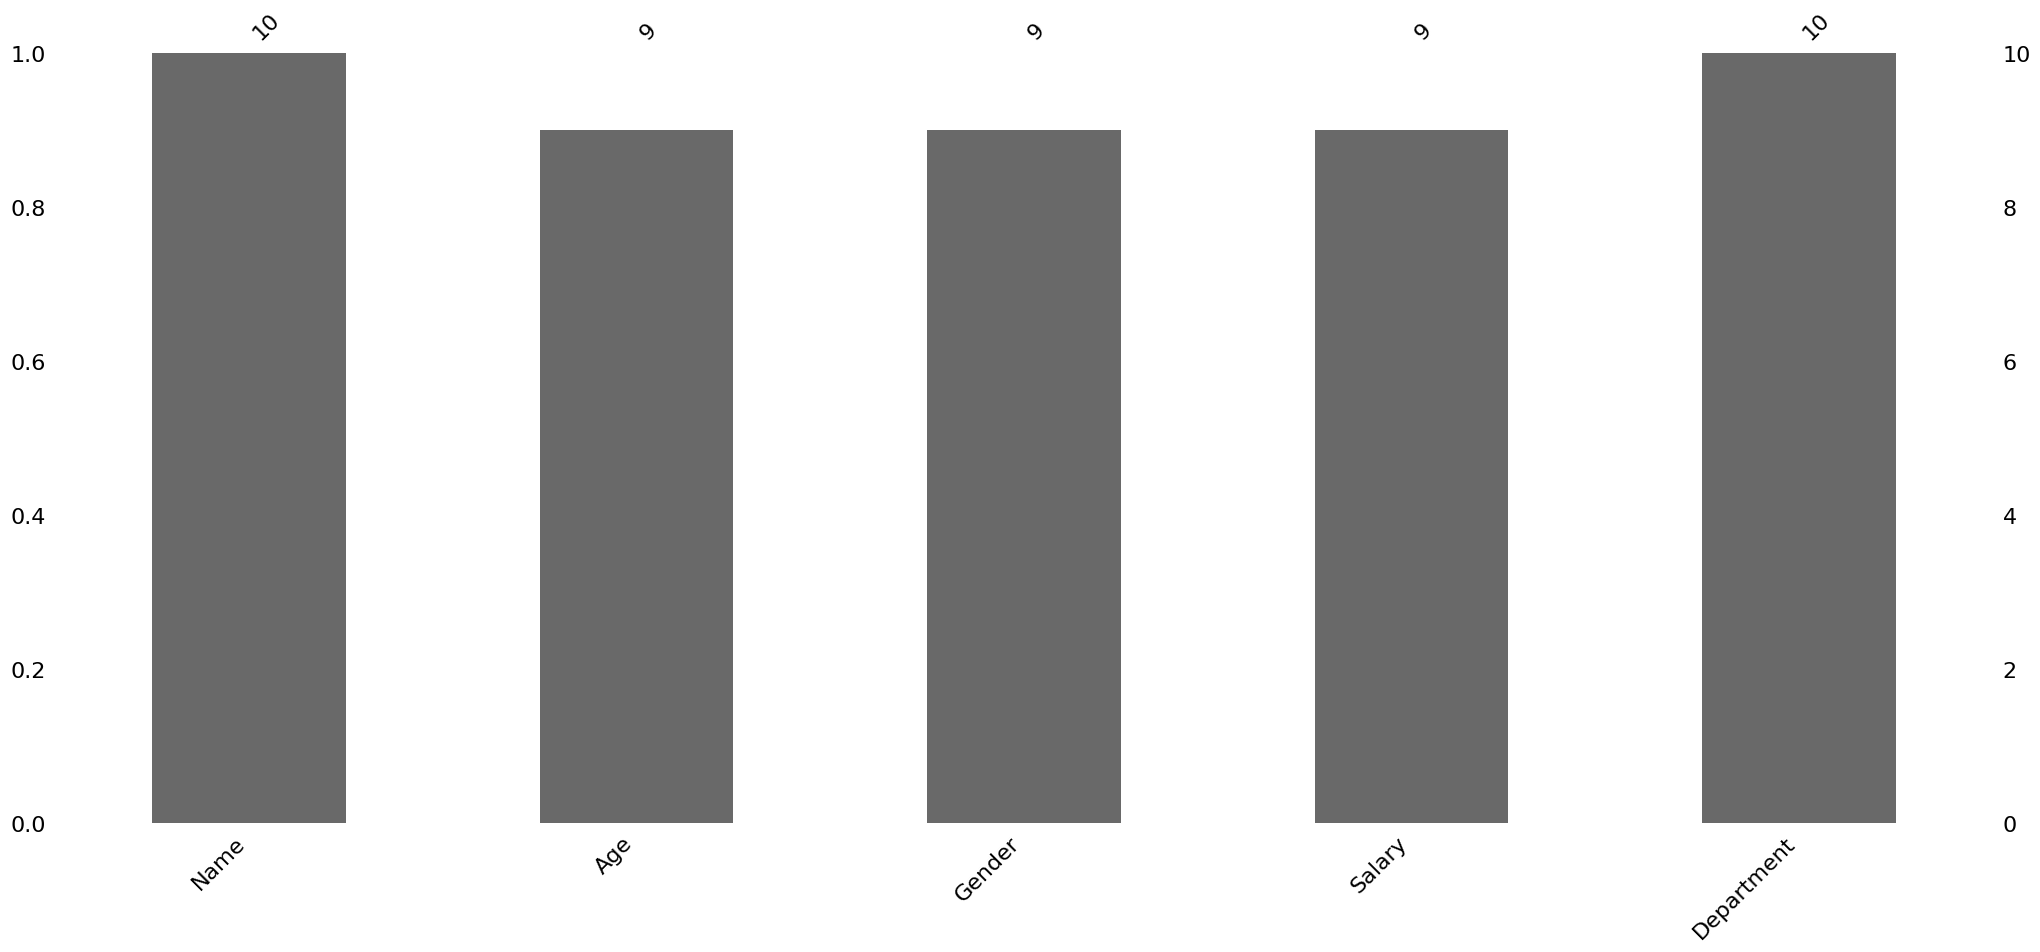

In [10]:
!pip install missingno
import missingno as msno
msno.bar(dd)

<Axes: >

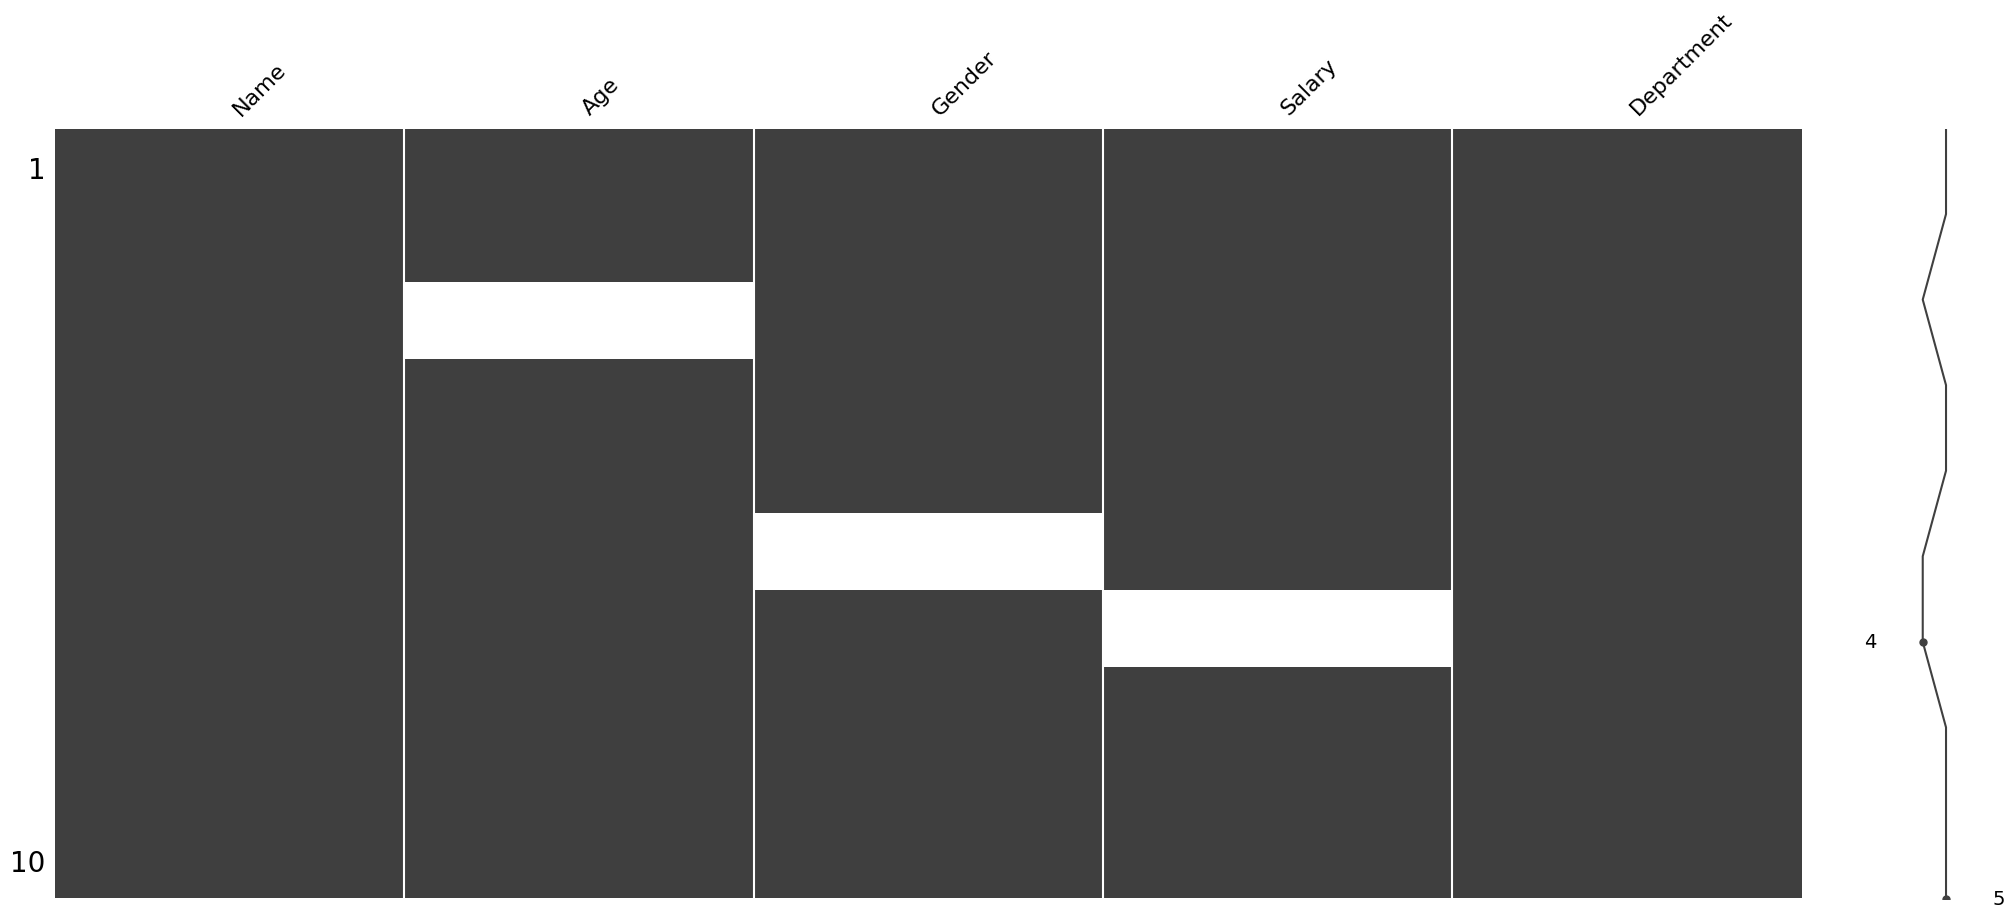

In [11]:
msno.matrix(dd)

<Axes: >

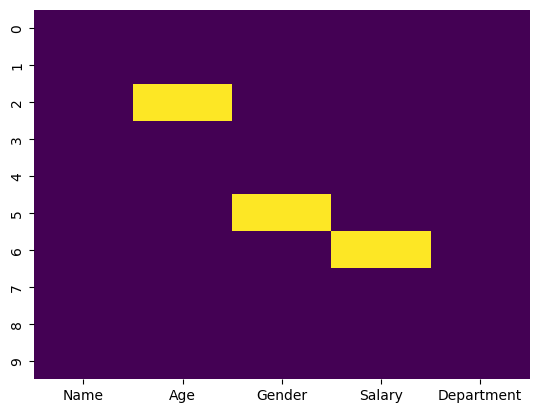

In [12]:
import seaborn as sns
sns.heatmap(dd.isnull(),cbar=False,cmap='viridis')

In [20]:
dd['Age'].fillna(dd['Age'].mean(),inplace=True)
dd['Salary'].fillna(dd['Salary'].mean(),inplace=True)
dd['Gender'].fillna(dd['Gender'].mode()[0],inplace=True)

/tmp/ipykernel_2018/738318695.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dd['Age'].fillna(dd['Age'].mean(),inplace=True)
/tmp/ipykernel_2018/738318695.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [14]:
dd1.head(12)

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [15]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
dd1[['Age']] = imp.fit_transform(dd1[['Age']])
dd1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


<Axes: >

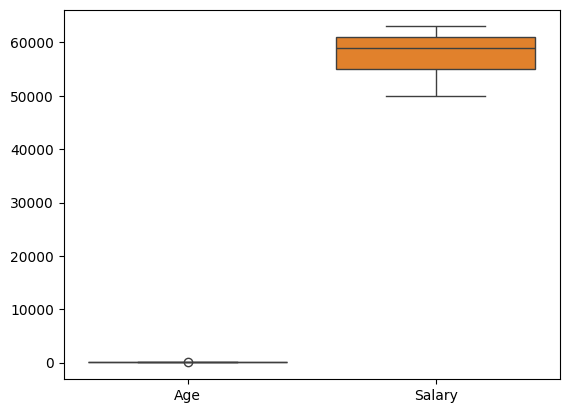

In [17]:
sns.boxplot(dd1)

<Axes: ylabel='Age'>

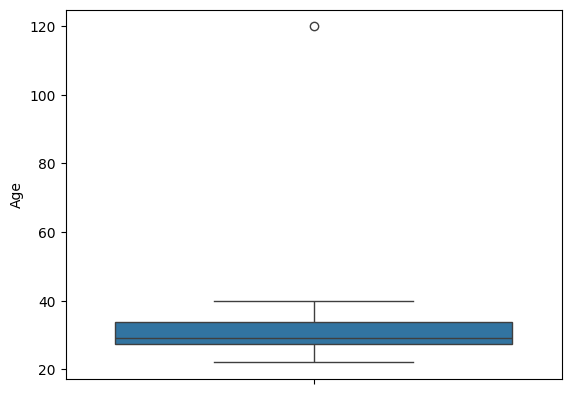

In [18]:
sns.boxplot(dd1['Age'])

In [19]:
Q1 = dd1['Age'].quantile(0.25)
Q3 = dd1['Age'].quantile(0.75)
IQR = Q3 - Q1


lowerbound = Q1-1.5*IQR
upperbound = Q3+1.5*IQR

outlier = dd1[(dd1['Age']<lowerbound) | (dd1['Age']>upperbound)]
print(outlier)

    Name    Age Gender  Salary Department
6  Grace  120.0      F     NaN    Finance


In [21]:
from scipy.stats import zscore
z_score = zscore(dd1['Age'])
dd1[np.abs(z_score)>2.5]

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,NaN,Finance


In [22]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.1)
dd1['outlier']= iso.fit_predict(dd1[['Age','Salary']])
dd1[dd1['outlier']==-1]

,Name,Age,Gender,Salary,Department,outlier
6,Grace,120.0,F,NaN,Finance,-1


In [23]:
from scipy.stats.mstats import winsorize
dd1['Age_winsorized'] = winsorize(dd1['Age'], limits=[0.05,0.05])
dd1['Salary_winsorized'] = winsorize(dd1['Salary'], limits=[0.05,0.05])

print(dd1[['Age','Age_winsorized','Salary','Salary_winsorized']])

     Age  Age_winsorized   Salary  Salary_winsorized
0   25.0            25.0  50000.0            50000.0
1   30.0            30.0  60000.0            60000.0
2   29.0            29.0  55000.0            55000.0
3   40.0            40.0  58000.0            58000.0
4   22.0            22.0  52000.0            52000.0
5   35.0            35.0  61000.0            61000.0
6  120.0           120.0      NaN                NaN
7   28.0            28.0  59000.0            59000.0
8   29.0            29.0  63000.0            63000.0
9   27.0            27.0  62000.0            62000.0


In [32]:
from scipy.stats import boxcox
dd1['Age_boxcox'], age_lambda = boxcox(dd1['Age'])
dd1['Salary_boxcox'], salary_lambda = boxcox(dd1['Salary'])

print(dd1[['Age_boxcox','Salary_boxcox']])

ValueError: The `x` argument of `boxcox_normmax` must contain only positive, finite, real numbers.

In [25]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

dd1[['Age_minmax','Salary_minmax']] = minmax.fit_transform(dd1[['Age','Salary']])

print(dd1[['Age_minmax','Salary_minmax']])

   Age_minmax  Salary_minmax
0    0.030612       0.000000
1    0.081633       0.769231
2    0.071429       0.384615
3    0.183673       0.615385
4    0.000000       0.153846
5    0.132653       0.846154
6    1.000000            NaN
7    0.061224       0.692308
8    0.071429       1.000000
9    0.051020       0.923077


In [26]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

dd1[['Age_standard','Salary_standard']] = scaler.fit_transform(dd1[['Age','Salary']])

print(dd1[['Age_standard','Salary_standard']])

   Age_standard  Salary_standard
0     -0.489487        -1.824501
1     -0.308196         0.521286
2     -0.344454        -0.651608
3      0.054387         0.052129
4     -0.598262        -1.355344
5     -0.126904         0.755865
6      2.955052              NaN
7     -0.380712         0.286707
8     -0.344454         1.225022
9     -0.416971         0.990443


In [27]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

dd1[['Age_power','Salary_power']] = pt.fit_transform(dd1[['Age','Salary']])

print(dd1[['Age_power','Salary_power']])

   Age_power  Salary_power
0  -0.911499     -1.584221
1   0.043753      0.423668
2  -0.108436     -0.809933
3   0.989428     -0.136350
4  -1.822158     -1.319100
5   0.618211      0.741954
6   2.041784           NaN
7  -0.277302      0.131484
8  -0.108436      1.464310
9  -0.465344      1.088187


In [28]:
dd1['Age_log'] = np.log1p(dd1['Age'])
dd1['Salary_log'] = np.log1p(dd1['Salary'])

print(dd1[['Age_log','Salary_log']])

    Age_log  Salary_log
0  3.258097   10.819798
1  3.433987   11.002117
2  3.401197   10.915107
3  3.713572   10.968216
4  3.135494   10.859018
5  3.583519   11.018646
6  4.795791         NaN
7  3.367296   10.985310
8  3.401197   11.050906
9  3.332205   11.034906


In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dd3['Gender_Encoder']= le.fit_transform(dd3['Gender'])
dd3

,Name,Age,Gender,Salary,Department,Gender_Encoder
0,Alice,25.0,F,50000.0,HR,0
1,Bob,30.0,M,60000.0,Finance,1
2,Charlie,NaN,M,55000.0,IT,1
3,David,40.0,M,58000.0,HR,1
4,Eve,22.0,F,52000.0,IT,0
5,Frank,35.0,NaN,61000.0,Finance,2
6,Grace,120.0,F,NaN,Finance,0
7,Henry,28.0,M,59000.0,HR,1
8,Ivy,29.0,F,63000.0,IT,0
9,Jack,27.0,M,62000.0,Finance,1


In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dd3['Gender_Encoder']= le.fit_transform(dd3['Gender'])
dd3

,Name,Age,Gender,Salary,Department,Gender_Encoder
0,Alice,25.0,F,50000.0,HR,0
1,Bob,30.0,M,60000.0,Finance,1
2,Charlie,NaN,M,55000.0,IT,1
3,David,40.0,M,58000.0,HR,1
4,Eve,22.0,F,52000.0,IT,0
5,Frank,35.0,NaN,61000.0,Finance,2
6,Grace,120.0,F,NaN,Finance,0
7,Henry,28.0,M,59000.0,HR,1
8,Ivy,29.0,F,63000.0,IT,0
9,Jack,27.0,M,62000.0,Finance,1


In [31]:
dd3 = pd.get_dummies(dd3,columns=['Gender'],drop_first=True)
dd3

,Name,Age,Salary,Department,Gender_Encoder,Gender_M
0,Alice,25.0,50000.0,HR,0,False
1,Bob,30.0,60000.0,Finance,1,True
2,Charlie,NaN,55000.0,IT,1,True
3,David,40.0,58000.0,HR,1,True
4,Eve,22.0,52000.0,IT,0,False
5,Frank,35.0,61000.0,Finance,2,False
6,Grace,120.0,NaN,Finance,0,False
7,Henry,28.0,59000.0,HR,1,True
8,Ivy,29.0,63000.0,IT,0,False
9,Jack,27.0,62000.0,Finance,1,True
